# Das ptolemäische Weltbild — Simulation

Claudius Ptolemäus (ca. 100–170 n. Chr.) fasste im **Almagest** die antike Astronomie zu einem
rechnerischen Modell zusammen, das rund 1400 Jahre lang die Himmelsvorhersage beherrschte.

## Grundannahmen

1. Die **Erde ruht im Zentrum** der Welt (geozentrisch).
2. Alle Himmelskörper bewegen sich auf **Kreisen mit konstanter Geschwindigkeit** — der
   „vollkommenen“ Bewegung.
3. Reihenfolge von innen nach außen: Mond, Merkur, Venus, Sonne, Mars, Jupiter, Saturn,
   dahinter die Fixsternsphäre.

## Das Problem: rückläufige Bewegung (Retrogradation)

Planeten wandern vor den Fixsternen meist ostwärts, laufen aber zeitweise **rückwärts** und
beschreiben Schleifen. Ein einfacher Kreis um die Erde kann das nicht erklären.

## Ptolemäus' Werkzeuge

| Begriff | Idee |
|---|---|
| **Deferent** | großer Trägerkreis um (nahezu) die Erde |
| **Epizykel** | kleiner Kreis, dessen Mittelpunkt auf dem Deferenten läuft; der Planet sitzt auf dem Epizykel |
| **Exzenter** | der Deferent ist nicht exakt um die Erde zentriert |
| **Äquant** | Punkt, von dem aus gesehen der Epizykelmittelpunkt *gleichmäßig* umläuft |

Position eines Planeten (als komplexe Zahl bzw. 2D-Vektor):

$$\vec r(t) = \underbrace{R\,\big(\cos(\omega_D t),\,\sin(\omega_D t)\big)}_{\text{Deferent}}
\;+\; \underbrace{r\,\big(\cos(\omega_E t),\,\sin(\omega_E t)\big)}_{\text{Epizykel}}$$

Die Überlagerung zweier Kreisbewegungen erzeugt genau die beobachteten Schleifen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 8)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

# feste Farbe pro Planet (Farbe folgt dem Objekt, nie der Reihenfolge im Plot)
FARBE = {
    "Merkur":  "#2a78d6",
    "Venus":   "#eb6834",
    "Mars":    "#1baf7a",
    "Jupiter": "#eda100",
    "Saturn":  "#e87ba4",
}
ERDE_FARBE, SONNE_FARBE = "#3a3a38", "#c98500"

JAHR = 365.25  # Tage

## 1. Planetendaten

Heute wissen wir: Die Planeten umlaufen die Sonne. Aus Sicht der Erde addieren sich dabei
**zwei Kreisbewegungen** — die des Planeten und die (gespiegelte) der Erde. Genau das ist
Deferent + Epizykel! Ptolemäus' Modell ist daher (bei Kreisbahnen) *mathematisch äquivalent*
zum heliozentrischen, nur mit anderem Bezugspunkt.

| | Deferent | Epizykel |
|---|---|---|
| **äußere Planeten** (Mars, Jupiter, Saturn) | Bahn des Planeten um die Sonne | Bahn der Erde um die Sonne (1 Jahr) |
| **innere Planeten** (Merkur, Venus) | Bahn der Sonne um die Erde (1 Jahr) | Bahn des Planeten um die Sonne |

Daraus folgen Ptolemäus' Regeln: Bei Merkur und Venus liegt der Epizykelmittelpunkt **immer
auf der Linie Erde–Sonne**; bei den äußeren Planeten ist der Epizykelradius **immer parallel
zur Richtung Erde–Sonne**.

Ptolemäus kannte keine absoluten Entfernungen, nur das **Verhältnis Epizykel/Deferent**
(Deferent = 60 Einheiten). Die Werte aus dem Almagest liegen erstaunlich nah an den modernen:

In [2]:
# a = große Halbachse [AE], T = siderische Umlaufzeit [Jahre]
PLANETEN = {
    "Merkur":  dict(a=0.387, T=0.2408, innen=True,  almagest=22.5),
    "Venus":   dict(a=0.723, T=0.6152, innen=True,  almagest=43 + 10/60),
    "Mars":    dict(a=1.524, T=1.8808, innen=False, almagest=39.5),
    "Jupiter": dict(a=5.203, T=11.862, innen=False, almagest=11.5),
    "Saturn":  dict(a=9.537, T=29.457, innen=False, almagest=6.5),
}


def synodisch(T):
    # Zeit zwischen zwei gleichen Stellungen Planet-Erde-Sonne (z. B. Opposition zu Opposition)
    return 1 / abs(1 / T - 1)


print(f"{'Planet':<9}{'r/R Almagest':>14}{'r/R modern':>13}{'Abw.':>8}{'synod. Periode':>17}")
print("-" * 61)
for name, p in PLANETEN.items():
    modern = p["a"] if p["innen"] else 1 / p["a"]
    alm = p["almagest"] / 60
    print(f"{name:<9}{alm:>14.3f}{modern:>13.3f}{(alm / modern - 1) * 100:>7.1f}%"
          f"{synodisch(p['T']) * JAHR:>13.0f} Tage")

Planet     r/R Almagest   r/R modern    Abw.   synod. Periode
-------------------------------------------------------------
Merkur            0.375        0.387   -3.1%          116 Tage
Venus             0.719        0.723   -0.5%          584 Tage
Mars              0.658        0.656    0.3%          780 Tage
Jupiter           0.192        0.192   -0.3%          399 Tage
Saturn            0.108        0.105    3.3%          378 Tage


## 2. Das Modell

`ptolemaeus(name, t)` liefert die geozentrische Position in AE. Die Winkel starten bei $t=0$
alle bei $0°$ — eine vereinfachte, aber in sich konsistente Ausgangskonstellation.
Zusätzlich geben wir Deferent- und Epizykelmittelpunkt zurück, um die Konstruktion zu zeichnen.

In [3]:
def kreis(radius, periode, t, phase=0.0):
    """Gleichförmige Kreisbewegung: Position zur Zeit t (Jahre)."""
    w = 2 * np.pi * np.asarray(t) / periode + phase
    return radius * np.stack([np.cos(w), np.sin(w)], axis=-1)


def sonne(t):
    """Geozentrische Sonnenposition: 1 AE, Periode 1 Jahr."""
    return kreis(1.0, 1.0, t)


def ptolemaeus(name, t):
    """Geozentrisches Deferent-Epizykel-Modell.

    Rückgabe: (Planetenposition, Epizykelmittelpunkt) — Arrays der Form (..., 2) in AE.
    """
    p = PLANETEN[name]
    if p["innen"]:
        # Deferent: läuft mit der Sonne; Epizykel: Planetenbahn um die Sonne
        zentrum = sonne(t)
        epizykel = kreis(p["a"], p["T"], t)
    else:
        # Deferent: Planetenbahn; Epizykel: Erdbahn (= Richtung zur Sonne)
        zentrum = kreis(p["a"], p["T"], t)
        epizykel = sonne(t)
    return zentrum + epizykel, zentrum


def heliozentrisch(name, t):
    """Kopernikanisch: Planet und Erde kreisen um die Sonne (Sonne im Ursprung)."""
    p = PLANETEN[name]
    return kreis(p["a"], p["T"], t), kreis(1.0, 1.0, t, phase=np.pi)


def laenge(pos):
    """Ekliptikale Länge in Grad (stetig fortgesetzt, ohne 360°-Sprünge)."""
    return np.degrees(np.unwrap(np.arctan2(pos[..., 1], pos[..., 0])))

## 3. Die Konstruktion: Deferent und Epizykel für Mars

Momentaufnahme: Erde im Zentrum, der Epizykelmittelpunkt auf dem Deferenten, Mars auf dem
Epizykel. Der Epizykelradius zeigt stets in Richtung der Sonne.

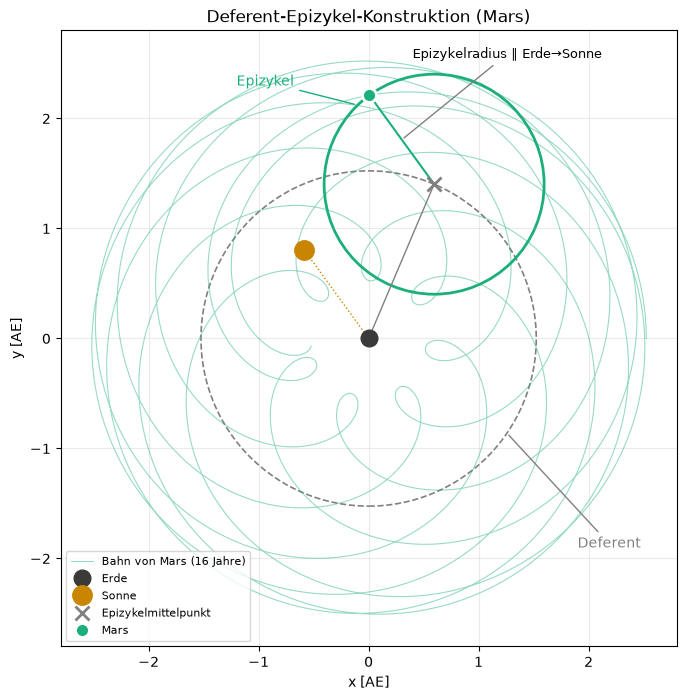

In [4]:
name, t0 = "Mars", 0.35
p = PLANETEN[name]
t = np.linspace(0, 16, 6000)
bahn, _ = ptolemaeus(name, t)
pos, zentrum = ptolemaeus(name, t0)
s = sonne(t0)

fig, ax = plt.subplots()
ax.plot(*bahn.T, color=FARBE[name], lw=0.8, alpha=0.45, label="Bahn von Mars (16 Jahre)")
ax.add_patch(Circle((0, 0), p["a"], fill=False, ls="--", color="gray", lw=1.2))
ax.add_patch(Circle(zentrum, 1.0, fill=False, color=FARBE[name], lw=2))
ax.plot([0, zentrum[0]], [0, zentrum[1]], color="gray", lw=1)
ax.plot([zentrum[0], pos[0]], [zentrum[1], pos[1]], color=FARBE[name], lw=1.5)
ax.plot([0, s[0]], [0, s[1]], color=SONNE_FARBE, lw=1, ls=":")

ax.plot(0, 0, "o", color=ERDE_FARBE, ms=12, label="Erde")
ax.plot(*s, "o", color=SONNE_FARBE, ms=14, label="Sonne")
ax.plot(*zentrum, "x", color="gray", ms=10, mew=2, label="Epizykelmittelpunkt")
ax.plot(*pos, "o", color=FARBE[name], ms=10, mec="white", mew=2, label="Mars")

ax.annotate("Deferent", (p["a"] * np.cos(-0.6), p["a"] * np.sin(-0.6)),
            xytext=(1.9, -1.9), arrowprops=dict(arrowstyle="-", color="gray"), color="gray")
ax.annotate("Epizykel", zentrum + np.array([-0.7, 0.72]), xytext=(-1.2, 2.3),
            arrowprops=dict(arrowstyle="-", color=FARBE[name]), color=FARBE[name])
ax.annotate("Epizykelradius ∥ Erde→Sonne", (pos + zentrum) / 2, xytext=(0.4, 2.55),
            arrowprops=dict(arrowstyle="-", color="gray"), fontsize=9)

ax.set(xlim=(-2.8, 2.8), ylim=(-2.8, 2.8), aspect="equal",
       xlabel="x [AE]", ylabel="y [AE]", title="Deferent-Epizykel-Konstruktion (Mars)")
ax.legend(loc="lower left", fontsize=8)
plt.show()

## 4. Das Weltbild: alle Planetenbahnen um die Erde

Links die inneren Planeten und die Sonne, rechts die äußeren (anderer Maßstab).
Die „Blütenmuster“ entstehen, weil Deferent und Epizykel unterschiedliche Perioden haben.
Jede Schlaufe entspricht einer Phase rückläufiger Bewegung.

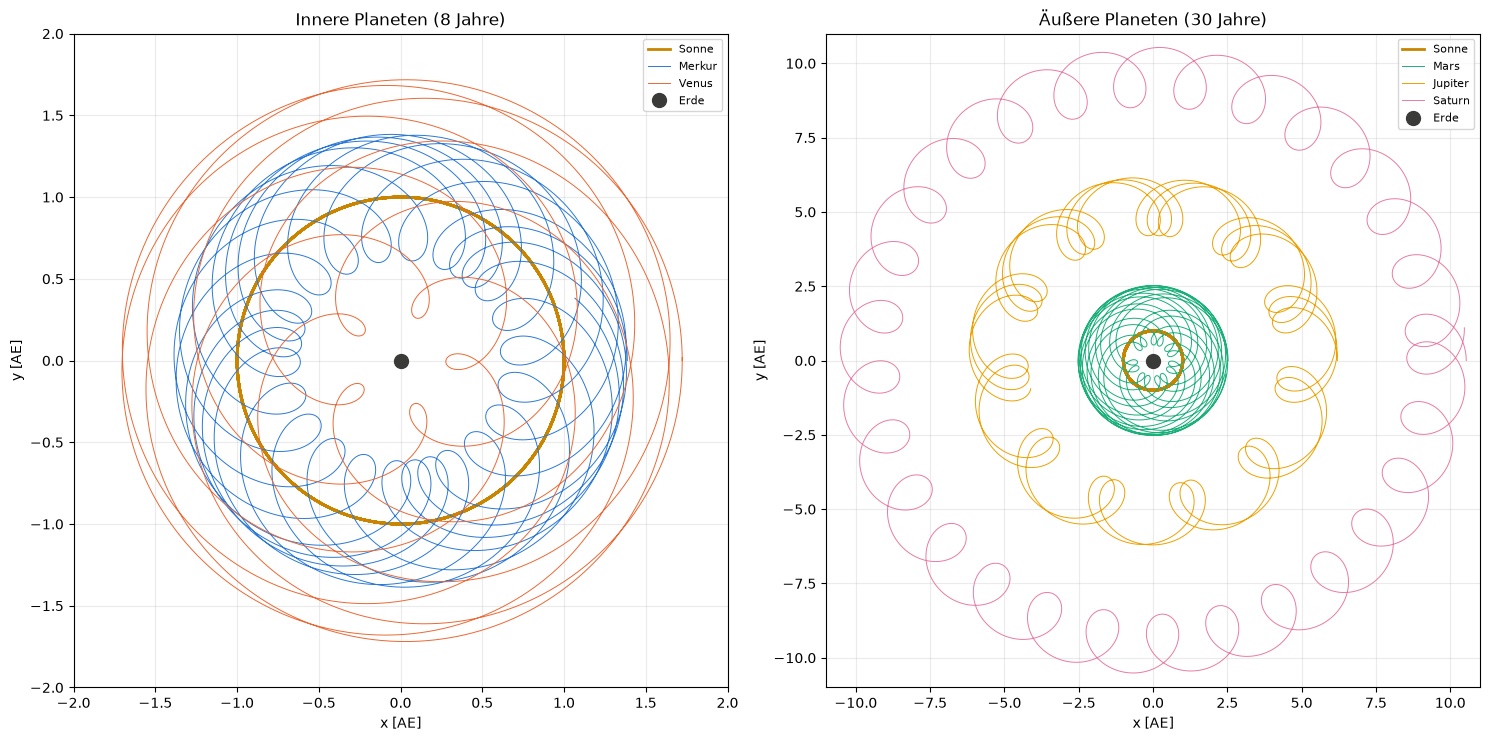

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))

gruppen = [
    (axes[0], ["Merkur", "Venus"], 8, 2.0, "Innere Planeten (8 Jahre)"),
    (axes[1], ["Mars", "Jupiter", "Saturn"], 30, 11.0, "Äußere Planeten (30 Jahre)"),
]
for ax, namen, dauer, grenze, titel in gruppen:
    t = np.linspace(0, dauer, 40000)
    ax.plot(*sonne(t).T, color=SONNE_FARBE, lw=2, label="Sonne")
    for name in namen:
        pos, _ = ptolemaeus(name, t)
        ax.plot(*pos.T, color=FARBE[name], lw=0.7, label=name)
    ax.plot(0, 0, "o", color=ERDE_FARBE, ms=10, label="Erde")
    ax.set(xlim=(-grenze, grenze), ylim=(-grenze, grenze), aspect="equal",
           xlabel="x [AE]", ylabel="y [AE]", title=titel)
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

## 5. Rückläufige Bewegung am Himmel

Was ein Beobachter tatsächlich sieht, ist nur die **Richtung** zum Planeten — die ekliptikale
Länge $\lambda(t)$. Wo $\dot\lambda < 0$, läuft der Planet rückwärts (grau hinterlegt).

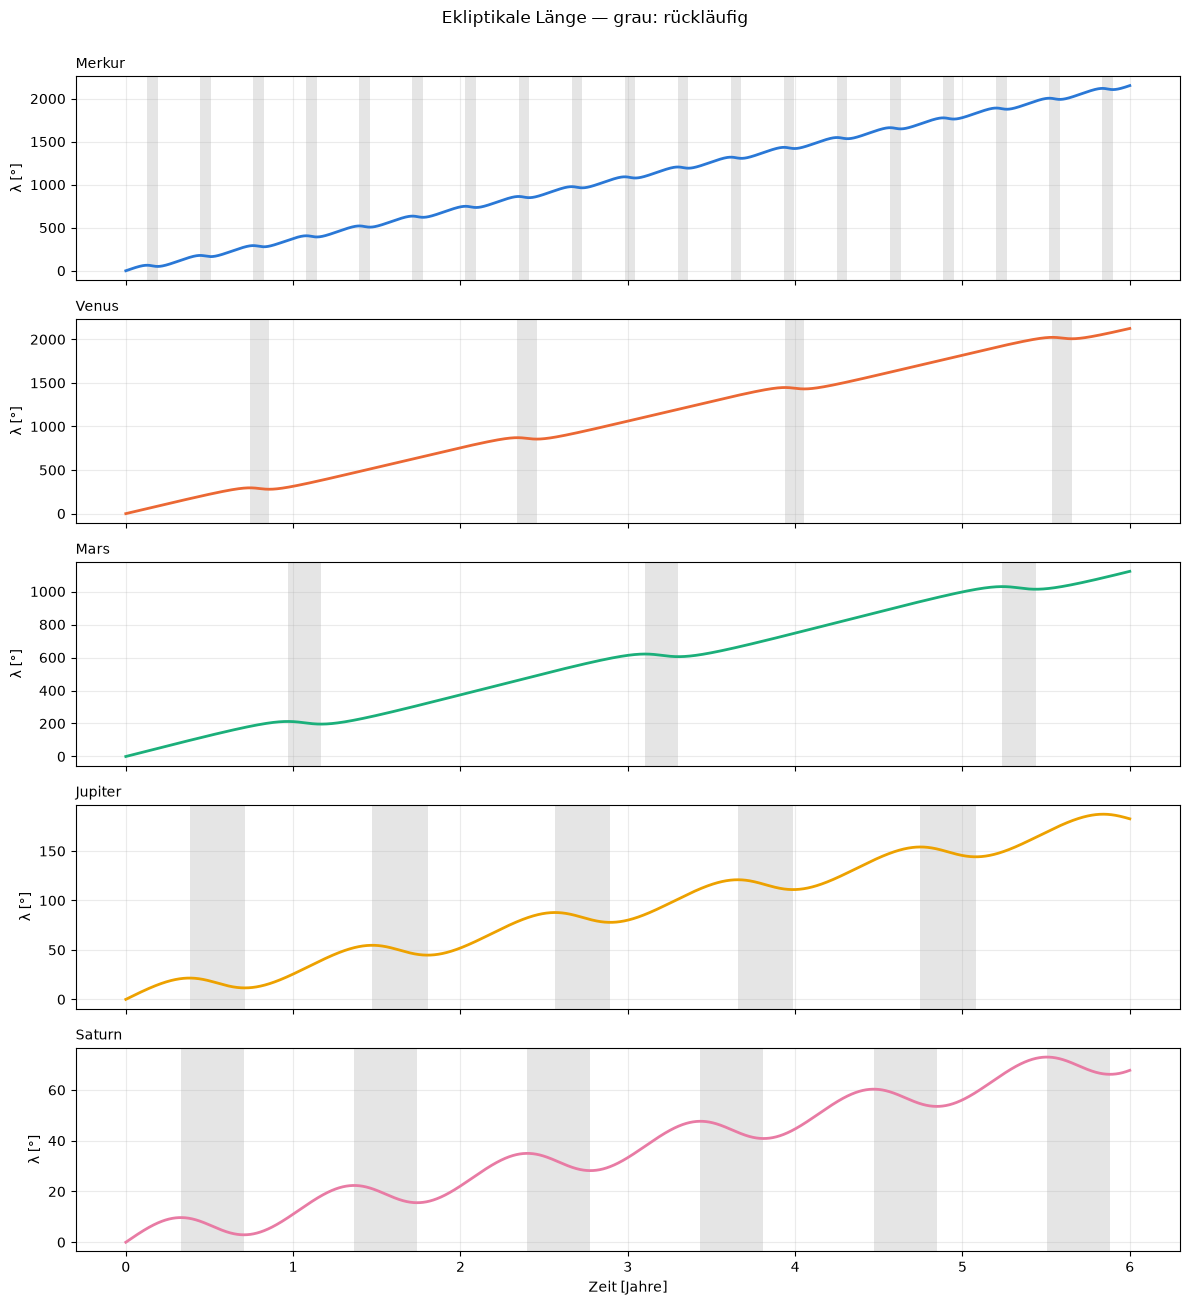

Planet     Dauer der Rückläufigkeit   rückläufiger Bogen
Merkur                      23 Tage                13.8°
Venus                       42 Tage                16.1°
Mars                        73 Tage                15.9°
Jupiter                    121 Tage                 9.9°
Saturn                     138 Tage                 6.8°


In [6]:
def retro_phasen(name, jahre=12, schritte_pro_tag=4):
    """Rückläufige Phasen finden: Liste von (Start, Ende, Dauer [d], Bogen [°])."""
    t = np.linspace(0, jahre, int(jahre * JAHR * schritte_pro_tag))
    lam = laenge(ptolemaeus(name, t)[0])
    rueck = np.gradient(lam, t) < 0
    kanten = np.flatnonzero(np.diff(rueck.astype(int)))
    phasen = []
    for i0, i1 in zip(kanten[rueck[kanten + 1]], kanten[~rueck[kanten + 1]]):
        if i1 > i0:
            phasen.append((t[i0], t[i1], (t[i1] - t[i0]) * JAHR, lam[i0] - lam[i1]))
    return t, lam, rueck, phasen


fig, axes = plt.subplots(5, 1, figsize=(12, 13), sharex=True)
for ax, name in zip(axes, PLANETEN):
    t, lam, rueck, phasen = retro_phasen(name, jahre=6)
    ax.plot(t, lam, color=FARBE[name], lw=2)
    for a, b, *_ in phasen:
        ax.axvspan(a, b, color="gray", alpha=0.2, lw=0)
    ax.set_ylabel("λ [°]")
    ax.set_title(name, loc="left", fontsize=10)
axes[-1].set_xlabel("Zeit [Jahre]")
fig.suptitle("Ekliptikale Länge — grau: rückläufig", y=1.0)
plt.tight_layout()
plt.show()

print(f"{'Planet':<9}{'Dauer der Rückläufigkeit':>26}{'rückläufiger Bogen':>21}")
for name in PLANETEN:
    *_, phasen = retro_phasen(name, jahre=40)
    dauer = np.mean([p[2] for p in phasen])
    bogen = np.mean([p[3] for p in phasen])
    print(f"{name:<9}{dauer:>21.0f} Tage{bogen:>20.1f}°")

### Die Schleife am Himmel

Die Ekliptik ist leicht gegen die Planetenbahnen geneigt. Gibt man dem Epizykel eine kleine
Neigung, wird aus dem Hin-und-her eine echte **Schleife** — so wie sie am Nachthimmel aussieht.
Hier Mars rund um eine Opposition (Mars-Bahnneigung 1,85°):

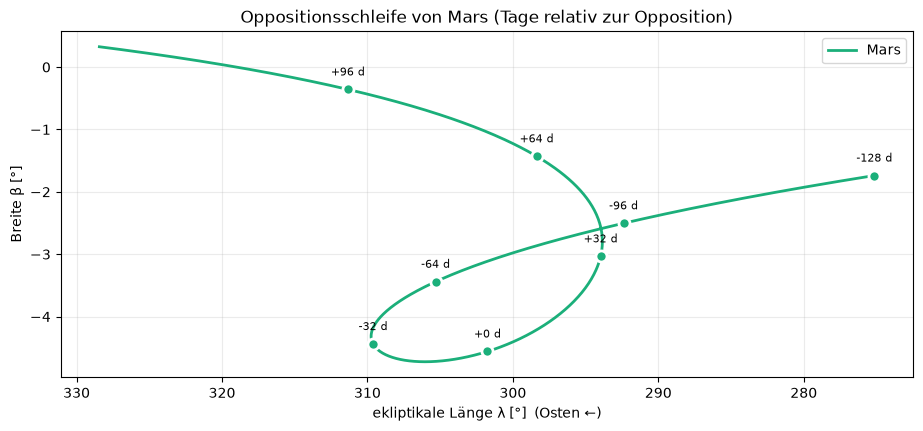

In [7]:
def breite(name, t, neigung=1.85):
    """Vereinfachte ekliptikale Breite: Planetenbahn um die Knotenlinie x geneigt."""
    p = PLANETEN[name]
    helio = kreis(p["a"], p["T"], t, phase=0.0)
    z = helio[..., 1] * np.sin(np.radians(neigung))   # Höhe über der Ekliptik [AE]
    geo, _ = ptolemaeus(name, t)
    return np.degrees(np.arctan2(z, np.hypot(*geo.T)))


# Opposition suchen: Mars genau gegenüber der Sonne
t = np.linspace(0, 6, 60000)
lam_m = laenge(ptolemaeus("Mars", t)[0]) % 360
lam_s = laenge(sonne(t)) % 360
t_opp = t[np.argmin(np.abs(((lam_m - lam_s) % 360) - 180))]

t = np.linspace(t_opp - 0.35, t_opp + 0.35, 800)
lam = laenge(ptolemaeus("Mars", t)[0])
lam -= 360 * np.floor(lam.min() / 360)   # in den Bereich 0…360° verschieben
beta = breite("Mars", t)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(lam, beta, color=FARBE["Mars"], lw=2, label="Mars")
monate = np.arange(0, len(t), 800 // 8)
ax.plot(lam[monate], beta[monate], "o", color=FARBE["Mars"], ms=8, mec="white", mew=2)
for i in monate:
    ax.annotate(f"{(t[i] - t_opp) * JAHR:+.0f} d", (lam[i], beta[i]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8)
ax.invert_xaxis()   # Blick nach Süden: Osten links
ax.set(xlabel="ekliptikale Länge λ [°]  (Osten ←)", ylabel="Breite β [°]",
       title="Oppositionsschleife von Mars (Tage relativ zur Opposition)")
ax.legend()
plt.show()

## 6. Äquivalenz mit dem heliozentrischen Modell

Wir berechnen die Richtung Erde→Planet einmal ptolemäisch und einmal kopernikanisch.
Bei Kreisbahnen sind beide Ergebnisse **identisch** — die Beobachtungsdaten konnten zwischen
den Modellen nicht unterscheiden. Kopernikus' Vorteil (1543) war zunächst vor allem die
Einfachheit: Die Retrogradation folgt ganz natürlich aus dem „Überholen“.

maximale Abweichung der Positionen Erde→Planet:
  Merkur   1.08e-14 AE
  Venus    1.08e-14 AE
  Mars     1.09e-14 AE
  Jupiter  1.15e-14 AE
  Saturn   1.07e-14 AE


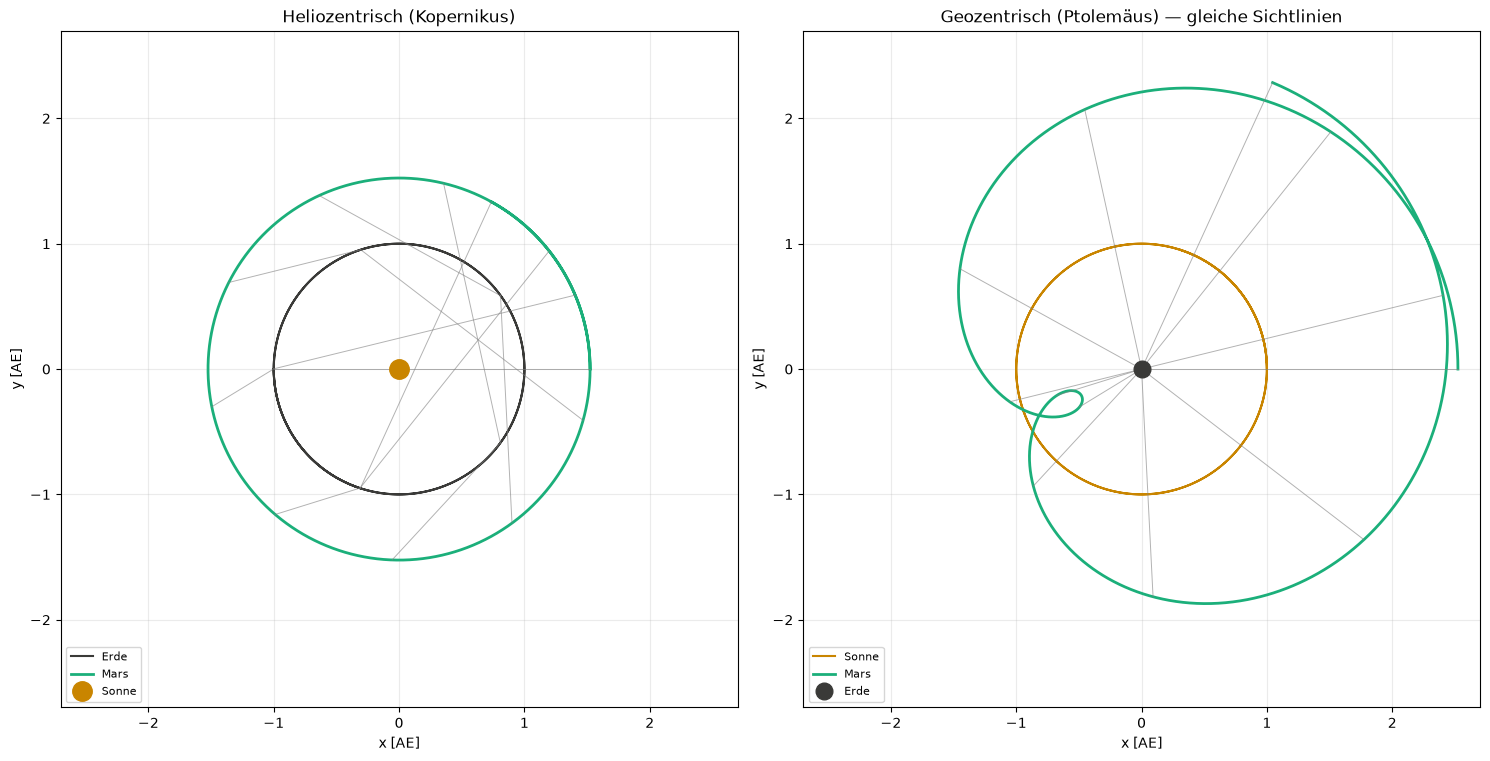

In [8]:
t = np.linspace(0, 20, 20000)
print("maximale Abweichung der Positionen Erde→Planet:")
for name in PLANETEN:
    geo, _ = ptolemaeus(name, t)
    planet, erde = heliozentrisch(name, t)
    print(f"  {name:<8} {np.abs(geo - (planet - erde)).max():.2e} AE")

# Visualisierung für Mars: zwei Blickwinkel auf dieselbe Bewegung
name = "Mars"
t = np.linspace(0, 2.2, 3000)
geo, _ = ptolemaeus(name, t)
planet, erde = heliozentrisch(name, t)
marken = np.linspace(0, len(t) - 1, 12).astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7.5))

ax1.plot(*erde.T, color=ERDE_FARBE, lw=1.5, label="Erde")
ax1.plot(*planet.T, color=FARBE[name], lw=2, label=name)
for i in marken:
    ax1.plot(*zip(erde[i], planet[i]), color="gray", lw=0.7, alpha=0.6)
ax1.plot(0, 0, "o", color=SONNE_FARBE, ms=14, label="Sonne")
ax1.set(title="Heliozentrisch (Kopernikus)", aspect="equal",
        xlim=(-2.7, 2.7), ylim=(-2.7, 2.7), xlabel="x [AE]", ylabel="y [AE]")
ax1.legend(loc="lower left", fontsize=8)

ax2.plot(*sonne(t).T, color=SONNE_FARBE, lw=1.5, label="Sonne")
ax2.plot(*geo.T, color=FARBE[name], lw=2, label=name)
for i in marken:
    ax2.plot(*zip((0, 0), geo[i]), color="gray", lw=0.7, alpha=0.6)
ax2.plot(0, 0, "o", color=ERDE_FARBE, ms=12, label="Erde")
ax2.set(title="Geozentrisch (Ptolemäus) — gleiche Sichtlinien", aspect="equal",
        xlim=(-2.7, 2.7), ylim=(-2.7, 2.7), xlabel="x [AE]", ylabel="y [AE]")
ax2.legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()

## 7. Exzenter und Äquant

Echte Planetenbahnen sind Ellipsen (Kepler, 1609): Der Planet ist mal schneller, mal
langsamer. Ptolemäus bildete das ohne Ellipsen nach:

* **Exzenter:** Der Kreis ist um den Abstand $e$ gegen die Erde verschoben.
* **Äquant:** Der Punkt, von dem aus die Bewegung *gleichförmig* erscheint, liegt spiegelbildlich
  auf der anderen Seite des Kreismittelpunkts (Abstand $e$ — „Halbierung der Exzentrizität“).

Wir vergleichen die Länge der Marsbahn (Exzentrizität $e = 0{,}0934$) in vier Modellen mit der
Kepler-Ellipse. Die Abweichung wird in **Bogenminuten** gemessen.

Modell                              max. Fehler gegenüber Kepler
konzentrischer Kreis                               642.8 Bogenmin.
Exzenter, Abstand e                                321.4 Bogenmin.
Exzenter, Abstand 2e (Hipparch)                     26.8 Bogenmin.
Exzenter + Äquant (Ptolemäus)                        9.0 Bogenmin.


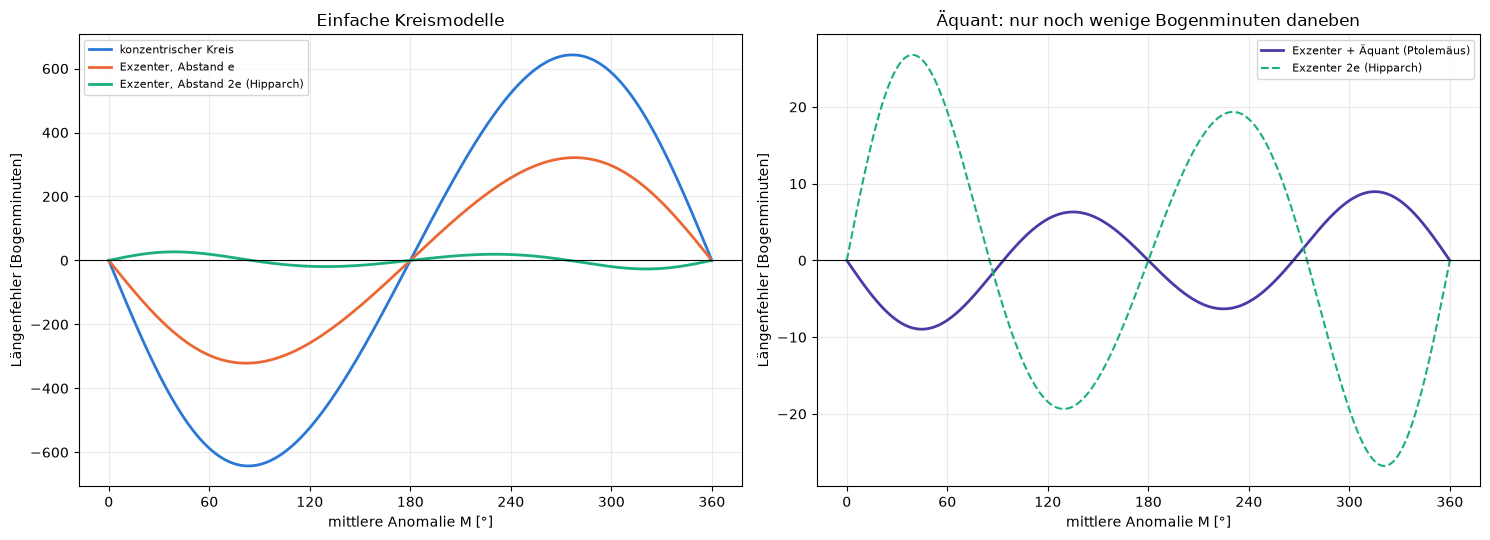

In [9]:
def kepler_anomalie(M, e):
    """Wahre Anomalie aus mittlerer Anomalie (Kepler-Gleichung, Newton-Verfahren)."""
    E = M.copy()
    for _ in range(30):
        E -= (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
    return 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2), np.sqrt(1 - e) * np.cos(E / 2))


def kreismodell(M, beobachter, aequant):
    """Kreis (Radius 1, Mittelpunkt 0). Gleichförmiger Umlauf um Punkt (-aequant, 0),
    beobachtet von (beobachter, 0). Rückgabe: beobachtete Länge und Position."""
    b = -aequant * np.cos(M)
    s = -b + np.sqrt(b**2 + 1 - aequant**2)          # Schnitt Strahl ↔ Kreis
    x, y = -aequant + s * np.cos(M), s * np.sin(M)
    return np.arctan2(y, x - beobachter), np.stack([x, y], axis=-1)


def bogenminuten(delta):
    return np.degrees(np.angle(np.exp(1j * delta))) * 60


e = 0.0934
M = np.linspace(0, 2 * np.pi, 3601)
nu = kepler_anomalie(M, e)

modelle = {
    "konzentrischer Kreis":            (0, 0),
    "Exzenter, Abstand e":             (e, 0),
    "Exzenter, Abstand 2e (Hipparch)": (2 * e, 0),
    "Exzenter + Äquant (Ptolemäus)":   (e, e),
}
farben = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
print(f"{'Modell':<34}{'max. Fehler gegenüber Kepler':>30}")
for (label, (beob, aeq)), farbe in zip(modelle.items(), farben):
    lam, _ = kreismodell(M, beob, aeq)
    fehler = bogenminuten(lam - nu)
    print(f"{label:<34}{np.abs(fehler).max():>22.1f} Bogenmin.")
    ziel = ax2 if aeq else ax1
    ziel.plot(np.degrees(M), fehler, color=farbe, lw=2, label=label)

ax1.set(title="Einfache Kreismodelle", xlabel="mittlere Anomalie M [°]",
        ylabel="Längenfehler [Bogenminuten]")
ax2.set(title="Äquant: nur noch wenige Bogenminuten daneben",
        xlabel="mittlere Anomalie M [°]", ylabel="Längenfehler [Bogenminuten]")
ax1.legend(fontsize=8)
ax2.legend(fontsize=8)
# Zum Vergleich: Hipparch-Exzenter auch rechts einblenden
lam, _ = kreismodell(M, 2 * e, 0)
ax2.plot(np.degrees(M), bogenminuten(lam - nu), color=farben[2], lw=1.5, ls="--",
         label="Exzenter 2e (Hipparch)")
ax2.legend(fontsize=8)
for ax in (ax1, ax2):
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(range(0, 361, 60))
plt.tight_layout()
plt.show()

Der Äquant reduziert den Fehler auf knapp **9 Bogenminuten** — weniger als ein Drittel des
Monddurchmessers und mit bloßem Auge kaum messbar. Erst Tycho Brahes präzise Messungen (~2′)
machten eine Abweichung dieser Größenordnung sichtbar: Kepler fand genau so eine Differenz von
etwa **8 Bogenminuten** zwischen Kreismodell und Tychos Marsdaten — und verwarf daraufhin den
Kreis zugunsten der Ellipse.

Geometrisch: Äquant-Kreis und Kepler-Ellipse fallen fast zusammen.

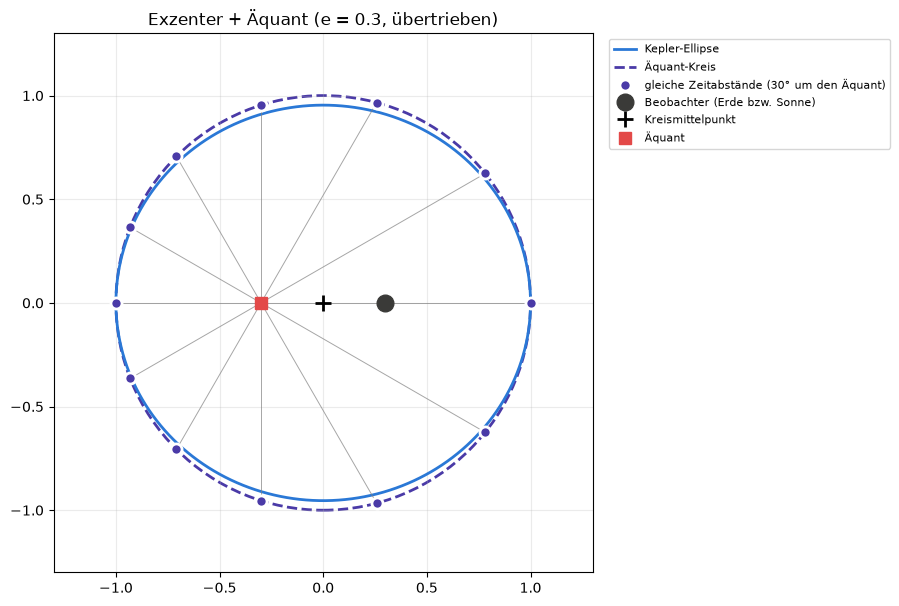

In [10]:
M_punkte = np.linspace(0, 2 * np.pi, 13)[:-1]
e_zeig = 0.3   # übertriebene Exzentrizität, damit man etwas sieht

fig, ax = plt.subplots(figsize=(11, 7))
# Kepler-Ellipse mit Brennpunkt (Beobachter) bei (e, 0), Mittelpunkt 0
E_ = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(E_), np.sqrt(1 - e_zeig**2) * np.sin(E_), color="#2a78d6", lw=2,
        label="Kepler-Ellipse")
ax.add_patch(Circle((0, 0), 1, fill=False, color="#4a3aa7", lw=2, ls="--"))
ax.plot([], [], color="#4a3aa7", ls="--", lw=2, label="Äquant-Kreis")

_, pos = kreismodell(M_punkte, e_zeig, e_zeig)
for p in pos:
    ax.plot([-e_zeig, p[0]], [0, p[1]], color="gray", lw=0.7, alpha=0.7)
ax.plot(*pos.T, "o", color="#4a3aa7", ms=8, mec="white", mew=2,
        label="gleiche Zeitabstände (30° um den Äquant)")

ax.plot(e_zeig, 0, "o", color=ERDE_FARBE, ms=12, label="Beobachter (Erde bzw. Sonne)")
ax.plot(0, 0, "+", color="k", ms=12, mew=2, label="Kreismittelpunkt")
ax.plot(-e_zeig, 0, "s", color="#e34948", ms=9, label="Äquant")
ax.set(aspect="equal", xlim=(-1.3, 1.3), ylim=(-1.3, 1.3),
       title=f"Exzenter + Äquant (e = {e_zeig}, übertrieben)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
plt.show()

## 8. Der Todesstoß: die Phasen der Venus

Die Richtung zur Venus (ihre **Elongation** von der Sonne) ist in beiden Modellen identisch —
deshalb funktionierte Ptolemäus' Modell für Positionsvorhersagen so gut.

Anders die **Beleuchtung**: Bei Ptolemäus liegt der Venus-Epizykel vollständig *zwischen* Erde
und Sonne. Die Venus kann dann nie „hinter“ der Sonne stehen und müsste immer als schmale
Sichel erscheinen. 1610 beobachtete **Galilei** mit dem Fernrohr jedoch den vollen Phasenzyklus
bis zur fast vollen Scheibe — unvereinbar mit dem ptolemäischen Modell.

Beleuchteter Anteil der Scheibe mit Phasenwinkel $\varphi$ (Winkel Sonne–Venus–Erde):
$\;k = \tfrac{1}{2}(1 + \cos\varphi)$

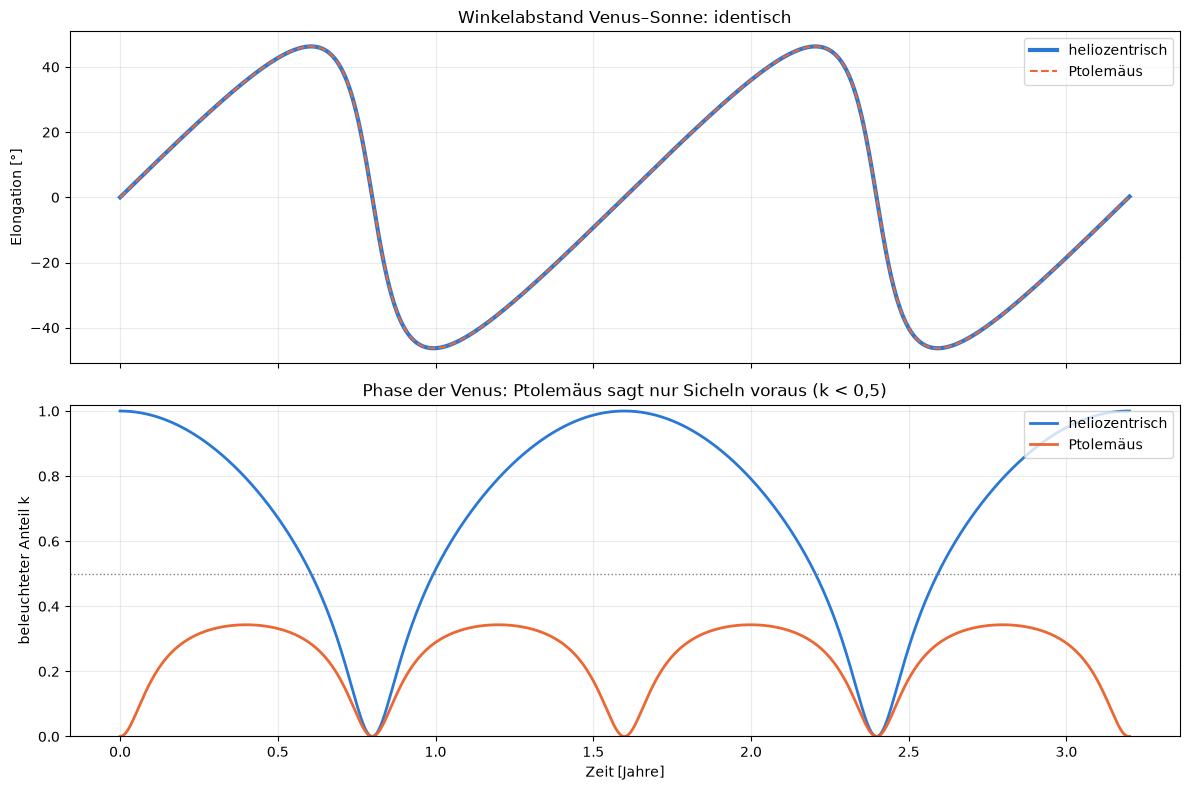

max. beleuchteter Anteil  Ptolemäus:      0.34
max. beleuchteter Anteil  heliozentrisch: 1.00


In [11]:
def beleuchtung(venus, sonne_pos, erde=np.zeros(2)):
    """Beleuchteter Anteil k aus dem Phasenwinkel am Ort der Venus."""
    zu_sonne, zu_erde = sonne_pos - venus, erde - venus
    cos_phi = np.sum(zu_sonne * zu_erde, axis=-1) / (
        np.linalg.norm(zu_sonne, axis=-1) * np.linalg.norm(zu_erde, axis=-1))
    return 0.5 * (1 + cos_phi)


t = np.linspace(0, 3.2, 4000)
S = sonne(t)

# Heliozentrisch (geozentrisch ausgedrückt): Venus = Sonne + Venusbahn
venus_helio, _ = ptolemaeus("Venus", t)

# Ptolemäisch: Epizykelmittelpunkt auf der Linie Erde–Sonne, aber UNTERHALB der Sonne.
# Absolute Größe beliebig, solange der Epizykel die Sonne nicht erreicht (hier 0,5 AE).
d = 0.5
richtung = S / np.linalg.norm(S, axis=-1, keepdims=True)
venus_ptol = d * richtung + d * PLANETEN["Venus"]["a"] * kreis(1, PLANETEN["Venus"]["T"], t)

elong = lambda v: np.degrees(np.angle(np.exp(1j * (np.arctan2(v[:, 1], v[:, 0])
                                                   - np.arctan2(S[:, 1], S[:, 0])))))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(t, elong(venus_helio), color="#2a78d6", lw=3, label="heliozentrisch")
ax1.plot(t, elong(venus_ptol), color="#eb6834", lw=1.5, ls="--", label="Ptolemäus")
ax1.set(ylabel="Elongation [°]", title="Winkelabstand Venus–Sonne: identisch")
ax1.legend(loc="upper right")

ax2.plot(t, beleuchtung(venus_helio, S), color="#2a78d6", lw=2, label="heliozentrisch")
ax2.plot(t, beleuchtung(venus_ptol, S), color="#eb6834", lw=2, label="Ptolemäus")
ax2.axhline(0.5, color="gray", lw=1, ls=":")
ax2.set(ylabel="beleuchteter Anteil k", xlabel="Zeit [Jahre]", ylim=(0, 1.02),
        title="Phase der Venus: Ptolemäus sagt nur Sicheln voraus (k < 0,5)")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"max. beleuchteter Anteil  Ptolemäus:      {beleuchtung(venus_ptol, S).max():.2f}")
print(f"max. beleuchteter Anteil  heliozentrisch: {beleuchtung(venus_helio, S).max():.2f}")

## 9. Interaktiv: eigene Epizykel bauen

Schieberegler für das Verhältnis der Radien und Perioden — so entstehen alle möglichen
Schleifenbahnen. Negative Perioden bedeuten Umlauf im Uhrzeigersinn.
(Benötigt `ipywidgets`; sonst wird ein statisches Beispiel gezeigt.)

ipywidgets nicht installiert — statisches Beispiel (Mars-ähnlich):


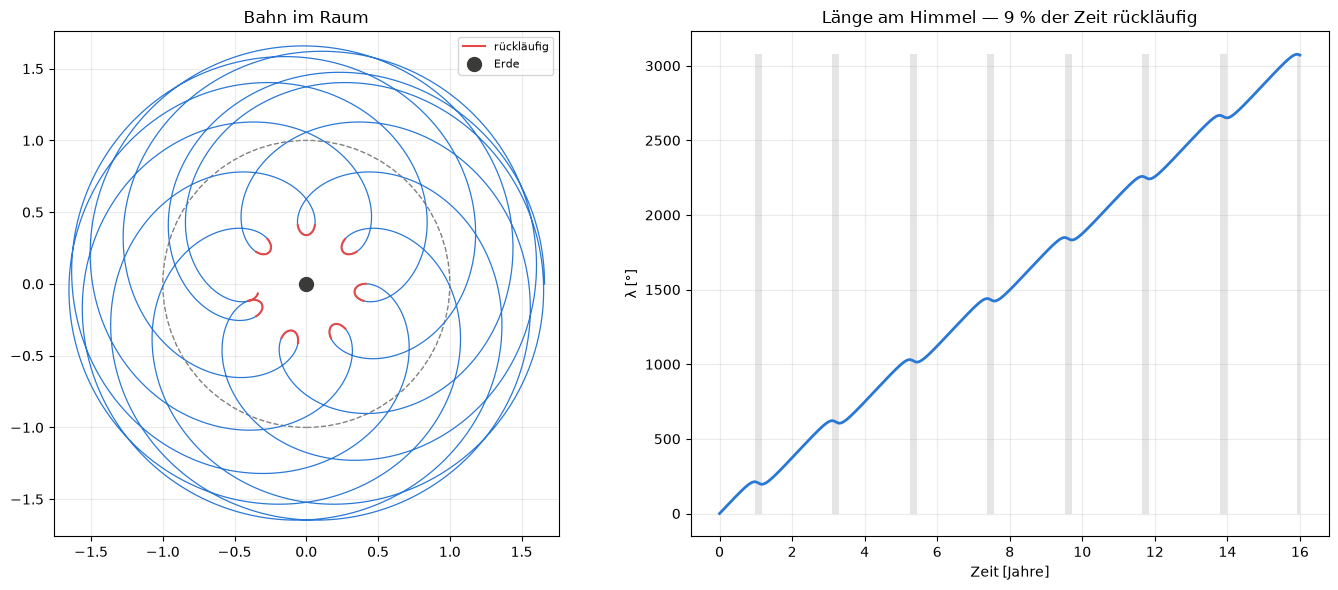

In [12]:
def epizykel_bahn(r_verh=0.4, T_def=5.0, T_epi=1.0, jahre=20.0):
    t = np.linspace(0, jahre, 8000)
    pos = kreis(1.0, T_def, t) + kreis(r_verh, T_epi, t)
    lam = laenge(pos)
    rueck = np.gradient(lam, t) < 0

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.plot(*pos.T, color="#2a78d6", lw=0.9)
    ax1.plot(*np.where(rueck[:, None], pos, np.nan).T, color="#e34948", lw=1.5,
             label="rückläufig")
    ax1.add_patch(Circle((0, 0), 1, fill=False, ls="--", color="gray"))
    ax1.plot(0, 0, "o", color=ERDE_FARBE, ms=10, label="Erde")
    g = 1.1 + r_verh
    ax1.set(aspect="equal", xlim=(-g, g), ylim=(-g, g), title="Bahn im Raum")
    ax1.legend(loc="upper right", fontsize=8)

    ax2.plot(t, lam, color="#2a78d6", lw=2)
    ax2.fill_between(t, lam.min(), lam.max(), where=rueck, color="gray", alpha=0.2, lw=0)
    ax2.set(xlabel="Zeit [Jahre]", ylabel="λ [°]",
            title=f"Länge am Himmel — {rueck.mean() * 100:.0f} % der Zeit rückläufig")
    plt.tight_layout()
    plt.show()


try:
    from ipywidgets import interact, FloatSlider

    interact(epizykel_bahn,
             r_verh=FloatSlider(value=0.4, min=0.0, max=1.5, step=0.02, description="r/R"),
             T_def=FloatSlider(value=5.0, min=-15, max=15, step=0.1, description="T Deferent"),
             T_epi=FloatSlider(value=1.0, min=-5, max=5, step=0.05, description="T Epizykel"),
             jahre=FloatSlider(value=20, min=1, max=60, step=1, description="Jahre"))
except ImportError:
    print("ipywidgets nicht installiert — statisches Beispiel (Mars-ähnlich):")
    epizykel_bahn(r_verh=0.66, T_def=1.88, T_epi=1.0, jahre=16)

## 10. Animation

Ptolemäisch vs. kopernikanisch nebeneinander — Mars über zwei synodische Perioden.
Die Zelle erzeugt eine abspielbare HTML-Animation (die Ausgabe ist im gespeicherten Notebook
nicht enthalten, um die Datei klein zu halten — einfach ausführen).

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

name = "Mars"
t = np.linspace(0, 2 * synodisch(PLANETEN[name]["T"]), 180)
geo, zentrum = ptolemaeus(name, t)
planet, erde = heliozentrisch(name, t)
S = sonne(t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, titel in ((ax1, "Ptolemäus (Erde ruht)"), (ax2, "Kopernikus (Sonne ruht)")):
    ax.set(aspect="equal", xlim=(-2.8, 2.8), ylim=(-2.8, 2.8), title=titel)

ax1.plot(0, 0, "o", color=ERDE_FARBE, ms=10)
ax1.add_patch(Circle((0, 0), PLANETEN[name]["a"], fill=False, ls="--", color="gray"))
spur1, = ax1.plot([], [], color=FARBE[name], lw=1.2)
epi = Circle((0, 0), 1.0, fill=False, color=FARBE[name], lw=1)
ax1.add_patch(epi)
sonne1, = ax1.plot([], [], "o", color=SONNE_FARBE, ms=12)
mars1, = ax1.plot([], [], "o", color=FARBE[name], ms=9)

ax2.plot(0, 0, "o", color=SONNE_FARBE, ms=12)
ax2.add_patch(Circle((0, 0), 1, fill=False, ls="--", color="gray"))
ax2.add_patch(Circle((0, 0), PLANETEN[name]["a"], fill=False, ls="--", color="gray"))
sicht, = ax2.plot([], [], color="gray", lw=0.8)
erde2, = ax2.plot([], [], "o", color=ERDE_FARBE, ms=9)
mars2, = ax2.plot([], [], "o", color=FARBE[name], ms=9)


def bild(i):
    spur1.set_data(*geo[: i + 1].T)
    epi.center = zentrum[i]
    sonne1.set_data([S[i, 0]], [S[i, 1]])
    mars1.set_data([geo[i, 0]], [geo[i, 1]])
    sicht.set_data(*zip(erde[i], erde[i] + 3 * (planet[i] - erde[i])))
    erde2.set_data([erde[i, 0]], [erde[i, 1]])
    mars2.set_data([planet[i, 0]], [planet[i, 1]])
    return spur1, epi, sonne1, mars1, sicht, erde2, mars2


anim = FuncAnimation(fig, bild, frames=len(t), interval=60, blit=True)
plt.close(fig)
HTML(anim.to_jshtml())

## 11. Einordnung

| | Ptolemäus (≈150) | Kopernikus (1543) | Kepler (1609) |
|---|---|---|---|
| Zentrum | Erde | Sonne | Sonne (im Brennpunkt) |
| Bahnform | Kreise + Epizykel + Äquant | Kreise (+ kleine Epizykel) | Ellipsen |
| Retrogradation | Epizykel | Überholvorgang | Überholvorgang |
| Genauigkeit | einige Bogenminuten bis ~1° | ähnlich wie Ptolemäus | ~1′ |
| Venusphasen | nur Sicheln ✗ | vollständig ✓ | vollständig ✓ |

**Warum hielt sich das Modell so lange?** Es war *rechnerisch erfolgreich*: Kreisbewegungen
lassen sich beliebig kombinieren (heute: Fourier-Reihen — mit genügend Epizykeln lässt sich
jede periodische Bahn nachbilden). Physikalisch sprachen die fehlende spürbare Erdbewegung und
die unbeobachtete Fixsternparallaxe gegen eine bewegte Erde.

## Aufgaben

1. Berechne mit `synodisch()` die synodische Periode von Jupiter. Wie viele Schleifen
   durchläuft Jupiter während eines Umlaufs (≈ 11,9 Jahre)? Prüfe am Plot in Abschnitt 4.
2. Warum ist der rückläufige Bogen von Saturn kleiner als der von Mars, obwohl die
   Rückläufigkeit länger dauert? (Tipp: Epizykel/Deferent-Verhältnis.)
3. Setze in Abschnitt 8 den Abstand `d` so, dass der Venus-Epizykel die Sonne gerade berührt.
   Welche maximale Phase ist dann möglich? Welcher Wert von `d` wäre nötig, um „Vollvenus“
   zu erhalten — und was hieße das für die Sonnen-Umlaufbahn der Venus?
4. Tycho Brahe (1588) ließ Merkur und Venus um die Sonne kreisen, die Sonne aber um die
   ruhende Erde. Baue dieses Modell nach und prüfe: Zeigt es die Venusphasen korrekt?

In [14]:
# Aufgabe 1 — Lösung
S_jup = synodisch(PLANETEN["Jupiter"]["T"])
print(f"synodische Periode Jupiter: {S_jup * JAHR:.0f} Tage")
print(f"Schleifen pro Umlauf: {PLANETEN['Jupiter']['T'] / S_jup:.1f}")

# Aufgabe 4 — Tycho: Venus um die Sonne, Sonne um die Erde.
# Das ist genau venus_helio aus Abschnitt 8 (in geozentrischen Koordinaten)!
t = np.linspace(0, 3.2, 4000)
venus_tycho = sonne(t) + kreis(PLANETEN["Venus"]["a"], PLANETEN["Venus"]["T"], t)
print(f"Tycho, max. beleuchteter Anteil der Venus: {beleuchtung(venus_tycho, sonne(t)).max():.2f}"
      "  → die Phasen allein widerlegen Tycho NICHT.")

synodische Periode Jupiter: 399 Tage
Schleifen pro Umlauf: 10.9
Tycho, max. beleuchteter Anteil der Venus: 1.00  → die Phasen allein widerlegen Tycho NICHT.
